In [1]:
# Imports
import os
from pathlib import Path
from urllib.parse import urlparse

from fastai.vision.all import *
from fastai.vision.gan import *
from fastai.vision.core import *

from ipywidgets import IntProgress
from IPython.display import display

import ipyplot

from ipynb.fs.full.Deink_00_Utils import *
from ipynb.fs.full.Deink_00_Utils import _get_sil_y 

Fastai Version: 2.7.12
Image Size: (480, 360)
Clean: True
Batch Size: 4


In [2]:
device = get_torch_device()

Total memory: 12884901888
Free memory: 4824629248
Used memory: 8060272640
CUDA is available: True


# Util Functions

In [3]:
def predict_image(img):
    img_fast = resize(img, split_idx=1) # Resize the image to match our training.
    #img_fast.show()
    
    # Run our prediction
    tensor_image, img_hr_tensor_base, preds_tensor_base = learn.predict(img_fast)
    
    # Show our results
    pil_image = PILImage.create(tensor_image)
    #pil_image.show()
    
    return pil_image

# Model Loading

In [4]:
# Load the model
%store -r
try:
    # See if the model file name is present from a prior notebook run
    model_file = silhouette_model_file 
except  NameError:
    model_file = './silhouette-resnet18-epocs40.pkl'
    
print(f"Using model: {model_file}")
learn = load_learner(model_file)

Using model: ./silhouette-resnet18-epocs40.pkl


# Process images

In [5]:
# Should we clean first?
if clean:
    print(f"Cleaning {path_sil_mask_predict}")
    for x in path_sil_mask_predict.glob("training-*"):
        if x.is_file():
            os.remove(x)    

Cleaning data/silhouette/mask-predict


In [6]:
raw_image_files = get_image_files(path_sil_tattooless)

tattoolesses = []
masks = []

#Render our status bar
max_count = len(raw_image_files)
f = IntProgress(min=0, max=max_count, description="Image Files: ") # instantiate the bar
display(f) # display the bar

# loop over all the images and process them
for raw_image_file in raw_image_files:
    #print(f'Processing: {raw_image_file}')
    f.value += 1
    
    # load the tattooless image
    basename = os.path.basename(raw_image_file)
    pil_image = PILImage.create(raw_image_file).convert('RGB')
    tattoolesses.append(pil_image)
    
    # do the prediction and save it off
    mask_img = predict_image(pil_image)
    masks.append(mask_img)
    mask_img.save(path_sil_mask_predict / basename)

IntProgress(value=0, description='Image Files: ', max=92)

Processed 92 tattoolesses


/opt/conda/lib/python3.11/site-packages/ipyplot/_utils.py:95: FutureWarning: The input object of type 'Image' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Image', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  return np.asarray(seq, dtype=type(seq[0]))



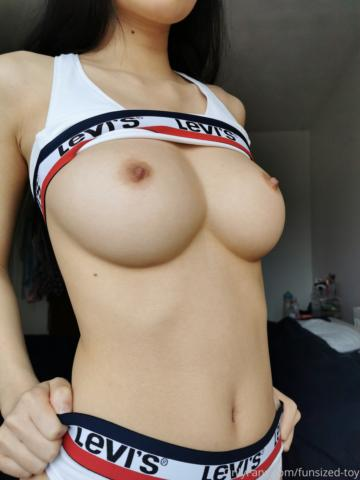
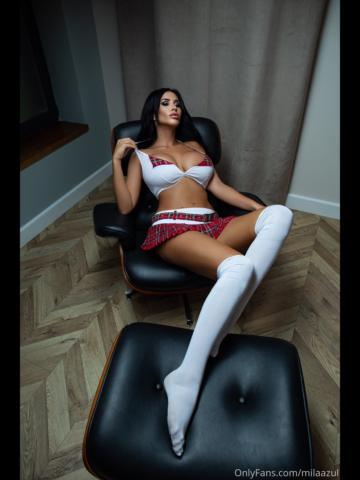
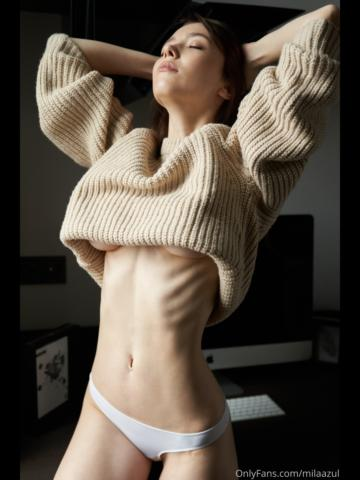
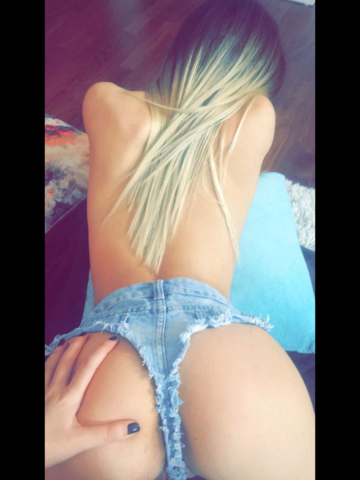
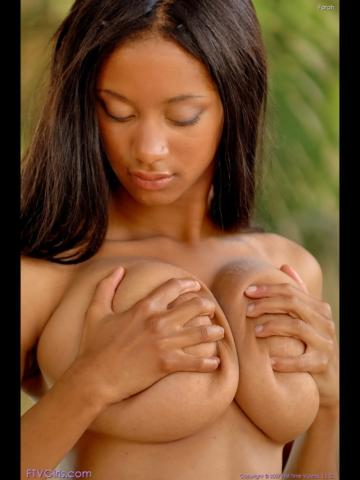


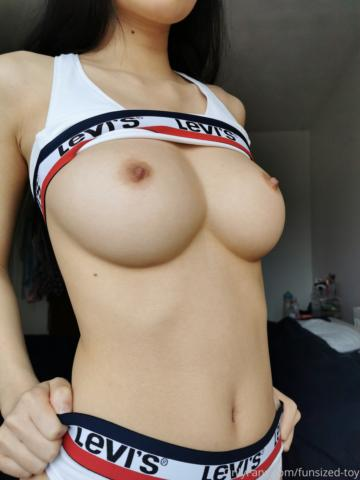
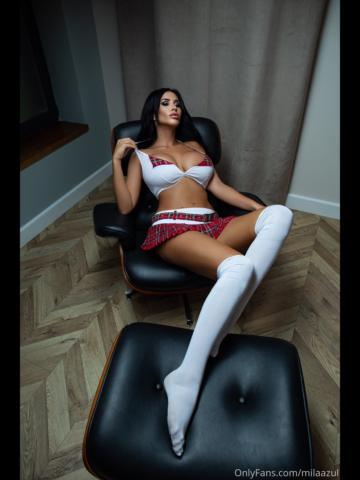
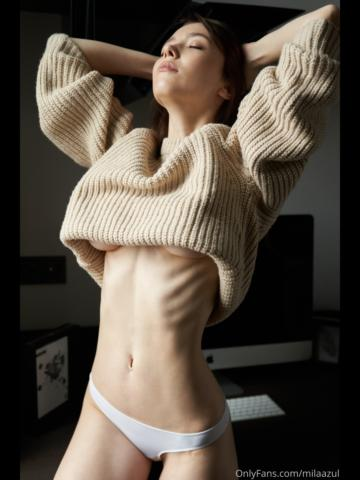
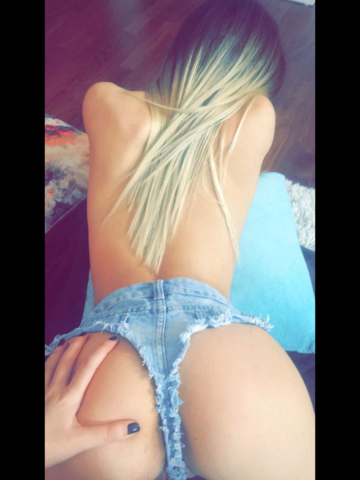
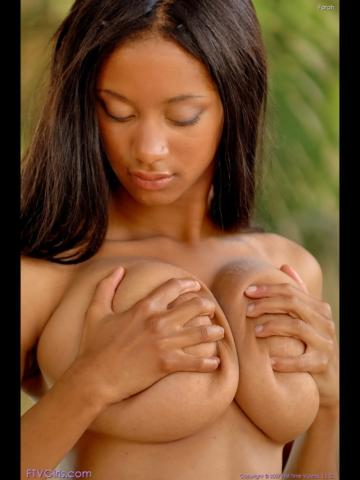

In [7]:
print(f"Processed {len(tattoolesses)} tattoolesses")
ipyplot.plot_images(tattoolesses, max_images=5, img_width=60)

Processed 92 masks


/opt/conda/lib/python3.11/site-packages/ipyplot/_utils.py:95: FutureWarning: The input object of type 'PILImage' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'PILImage', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  return np.asarray(seq, dtype=type(seq[0]))



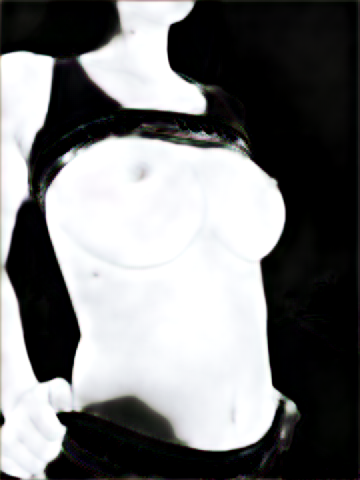
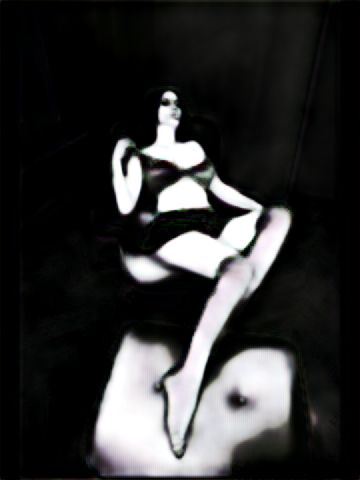
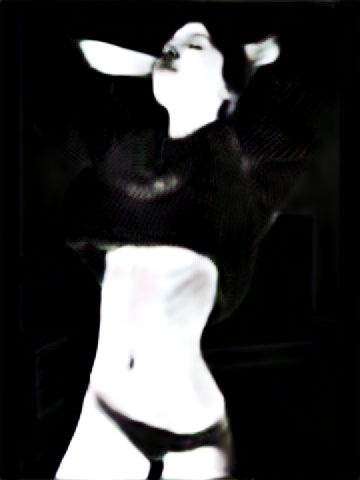
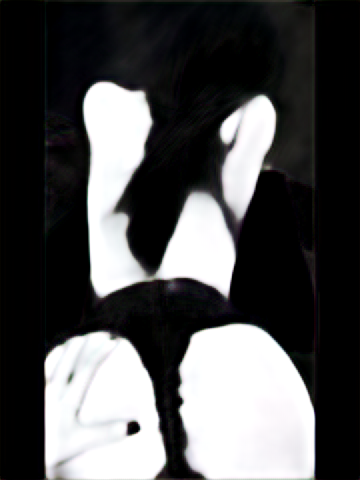
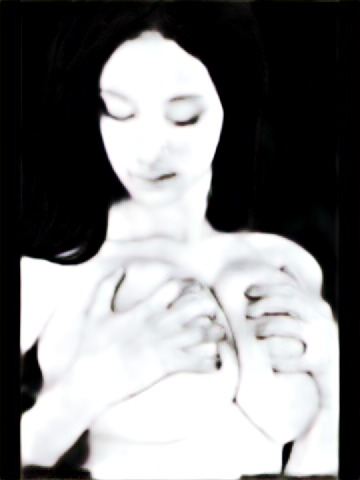


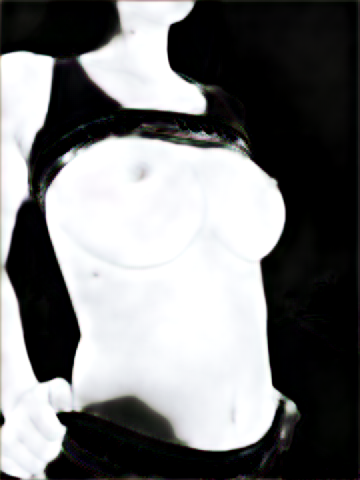
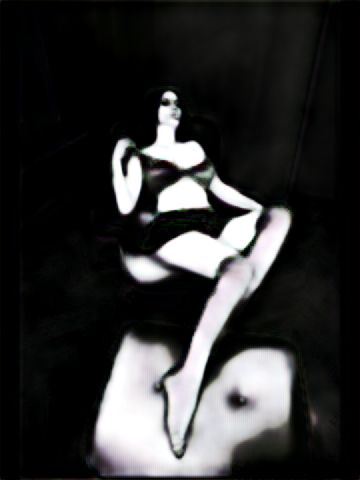
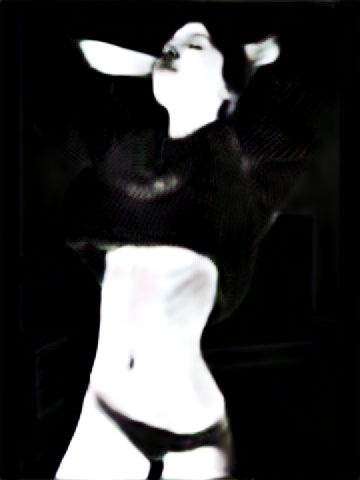
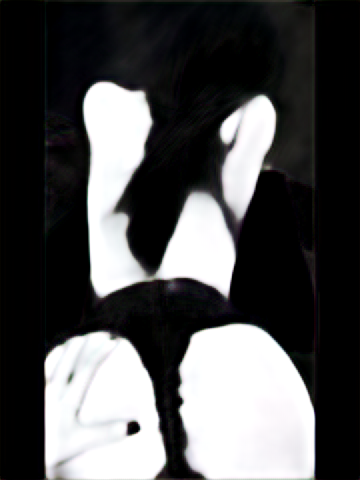
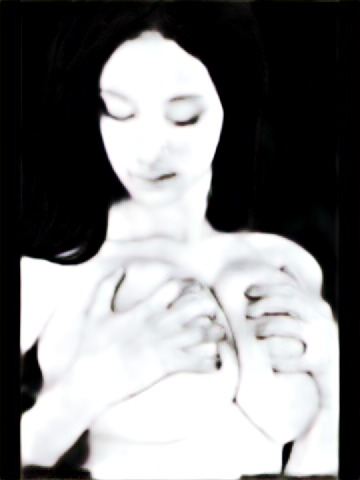

In [8]:
print(f"Processed {len(tattoolesses)} masks")
ipyplot.plot_images(masks, max_images=5, img_width=150)